# математический маятник

$\ddot\theta + \omega^2\theta = 0$, $\omega = \sqrt{g/l}$.
При $v = \dot\theta$ система имеет вид $\dot\theta = v$, $\dot v = -\omega^2\theta$.

Точное решение:
$$\theta(t) = \theta_0\cos(\omega t) + \frac{v_0}{\omega}\sin(\omega t),$$
$$v(t) = -\omega\theta_0\sin(\omega t) + v_0\cos(\omega t).$$

Энергии в линейной модели:
$$e_p = \frac{ml^2\omega^2\theta^2}{2}, \qquad e_k = \frac{ml^2v^2}{2}.$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt

g = 9.81
l = 1.0
m = 1.0
omega = np.sqrt(g / l)
theta_0 = 0.1
v_0 = 0.0
y_0 = np.array([theta_0, v_0])
t_end = 6.0
steps = [0.04, 0.02, 0.01]


In [2]:
def rhs(y):  # правая часть системы
    return np.array([y[1], -omega**2 * y[0]])


def euler_step(y, h):  # шаг явного эйлера
    return y + h * rhs(y)


def rk4_step(y, h):  # шаг rk4
    k_1 = rhs(y)
    k_2 = rhs(y + h * k_1 / 2)
    k_3 = rhs(y + h * k_2 / 2)
    k_4 = rhs(y + h * k_3)
    return y + h * (k_1 + 2 * k_2 + 2 * k_3 + k_4) / 6


def solve(step, h):  # расчёт на временной сетке
    n = round(t_end / h)
    t = np.linspace(0, t_end, n + 1)
    dt = t[1] - t[0]
    y = np.empty((n + 1, 2))
    y[0] = y_0
    for i in range(n):
        y[i + 1] = step(y[i], dt)
    return t, y


def exact(t):  # точное решение
    theta = theta_0 * np.cos(omega * t) + v_0 / omega * np.sin(omega * t)
    v = -omega * theta_0 * np.sin(omega * t) + v_0 * np.cos(omega * t)
    return np.column_stack((theta, v))


def energy(y):  # потенциальная и кинетическая энергии
    e_p = m * l**2 * omega**2 * y[:, 0]**2 / 2
    e_k = m * l**2 * y[:, 1]**2 / 2
    return e_p, e_k


In [3]:
results = []
for h in steps:
    t, y_euler = solve(euler_step, h)
    _, y_rk4 = solve(rk4_step, h)
    results.append((t, exact(t), y_euler, y_rk4))

names = ['точное', 'эйлер', 'rk4']
colors = ['black', 'tab:orange', 'tab:blue']
styles = ['-', '--', ':']

print(f"{'шаг, с':>8} {'метод':>8} {'макс. ошибка θ, рад':>22} {'изменение энергии, %':>24}")
for h, (t, y_exact, y_euler, y_rk4) in zip(steps, results):
    for name, y in [('эйлер', y_euler), ('rk4', y_rk4)]:
        error = np.max(np.abs(y[:, 0] - y_exact[:, 0]))
        e_p, e_k = energy(y)
        e = e_p + e_k
        drift = 100 * (e[-1] / e[0] - 1)
        print(f'{h:8.2f} {name:>8} {error:22.6e} {drift:24.6e}')


  шаг, с    метод    макс. ошибка θ, рад     изменение энергии, %
    0.04    эйлер           2.179102e-01             9.340971e+02
    0.04      rk4           3.572938e-06            -8.040278e-04
    0.02    эйлер           7.950385e-02             2.237807e+02
    0.02      rk4           2.226663e-07            -2.516301e-05
    0.01    эйлер           3.409426e-02             8.009449e+01
    0.01      rk4           1.390012e-08            -7.866340e-07


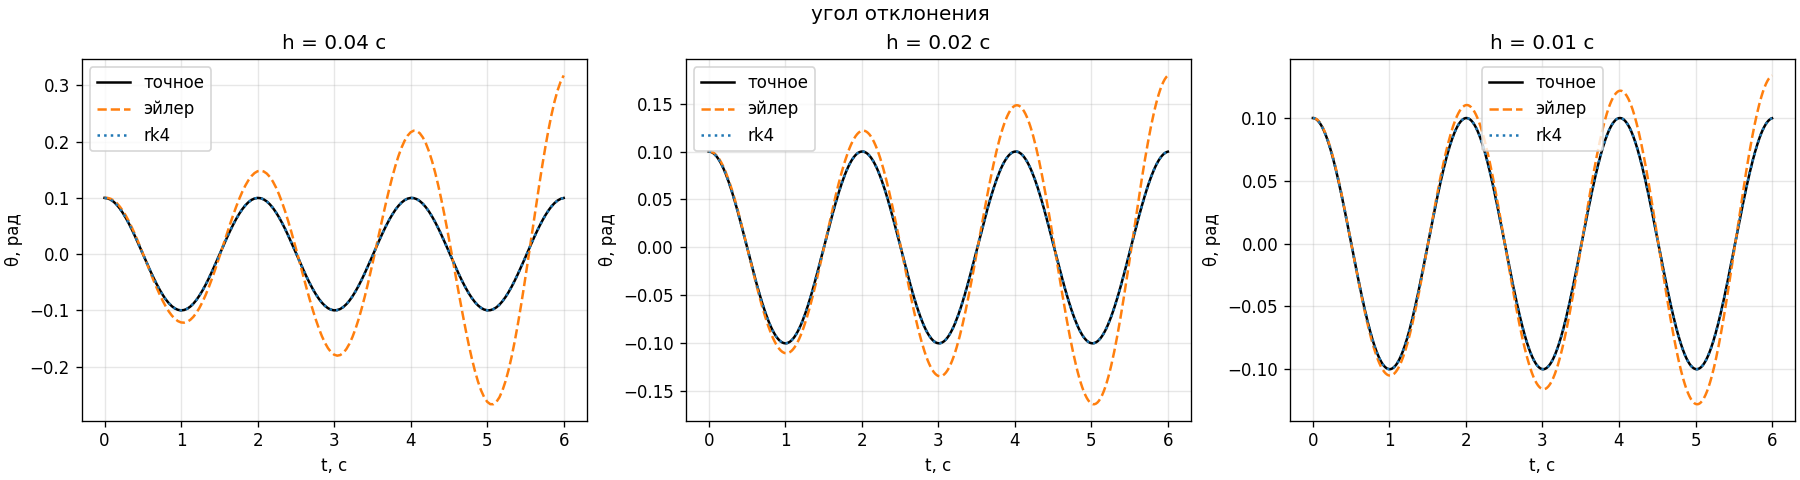

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
for ax, h, (t, *solutions) in zip(axes, steps, results):
    for y, name, color, style in zip(solutions, names, colors, styles):
        ax.plot(t, y[:, 0], label=name, color=color, linestyle=style)
    ax.set(title=f'h = {h} с', xlabel='t, с', ylabel='θ, рад')
    ax.grid(alpha=0.3)
    ax.legend()
fig.suptitle('угол отклонения')
plt.show()


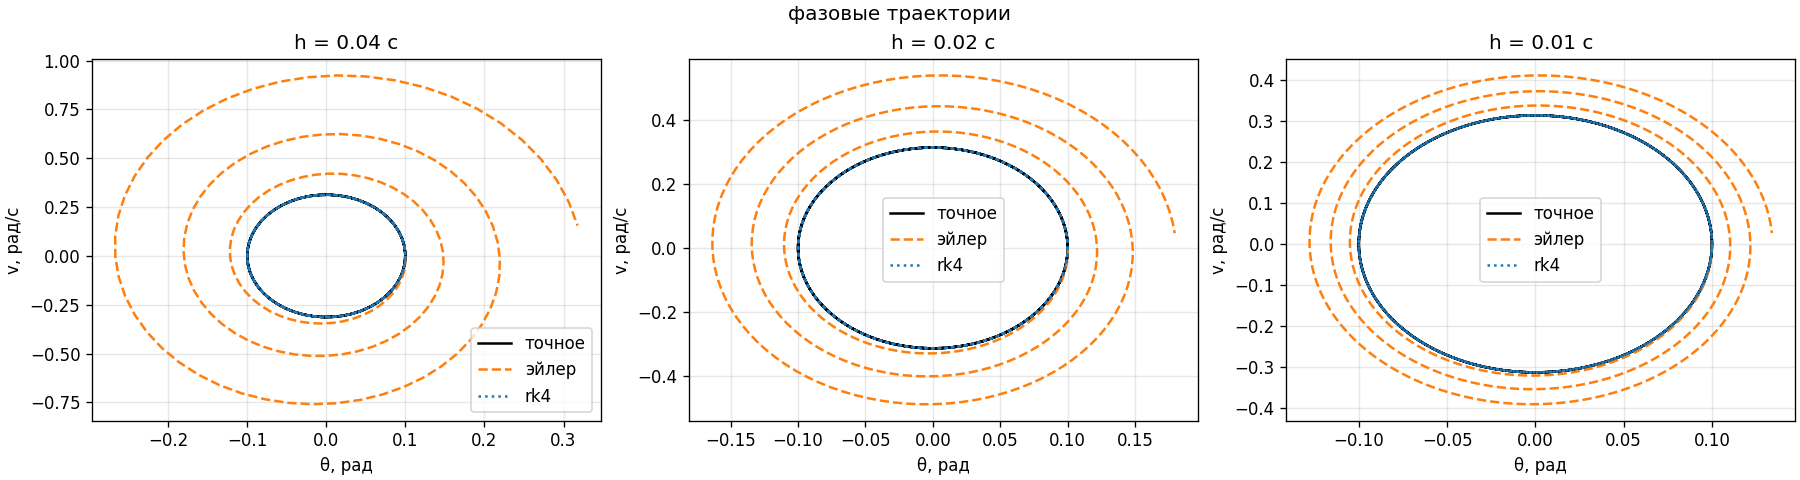

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
for ax, h, (t, *solutions) in zip(axes, steps, results):
    for y, name, color, style in zip(solutions, names, colors, styles):
        ax.plot(y[:, 0], y[:, 1], label=name, color=color, linestyle=style)
    ax.set(title=f'h = {h} с', xlabel='θ, рад', ylabel='v, рад/с')
    ax.grid(alpha=0.3)
    ax.legend()
fig.suptitle('фазовые траектории')
plt.show()


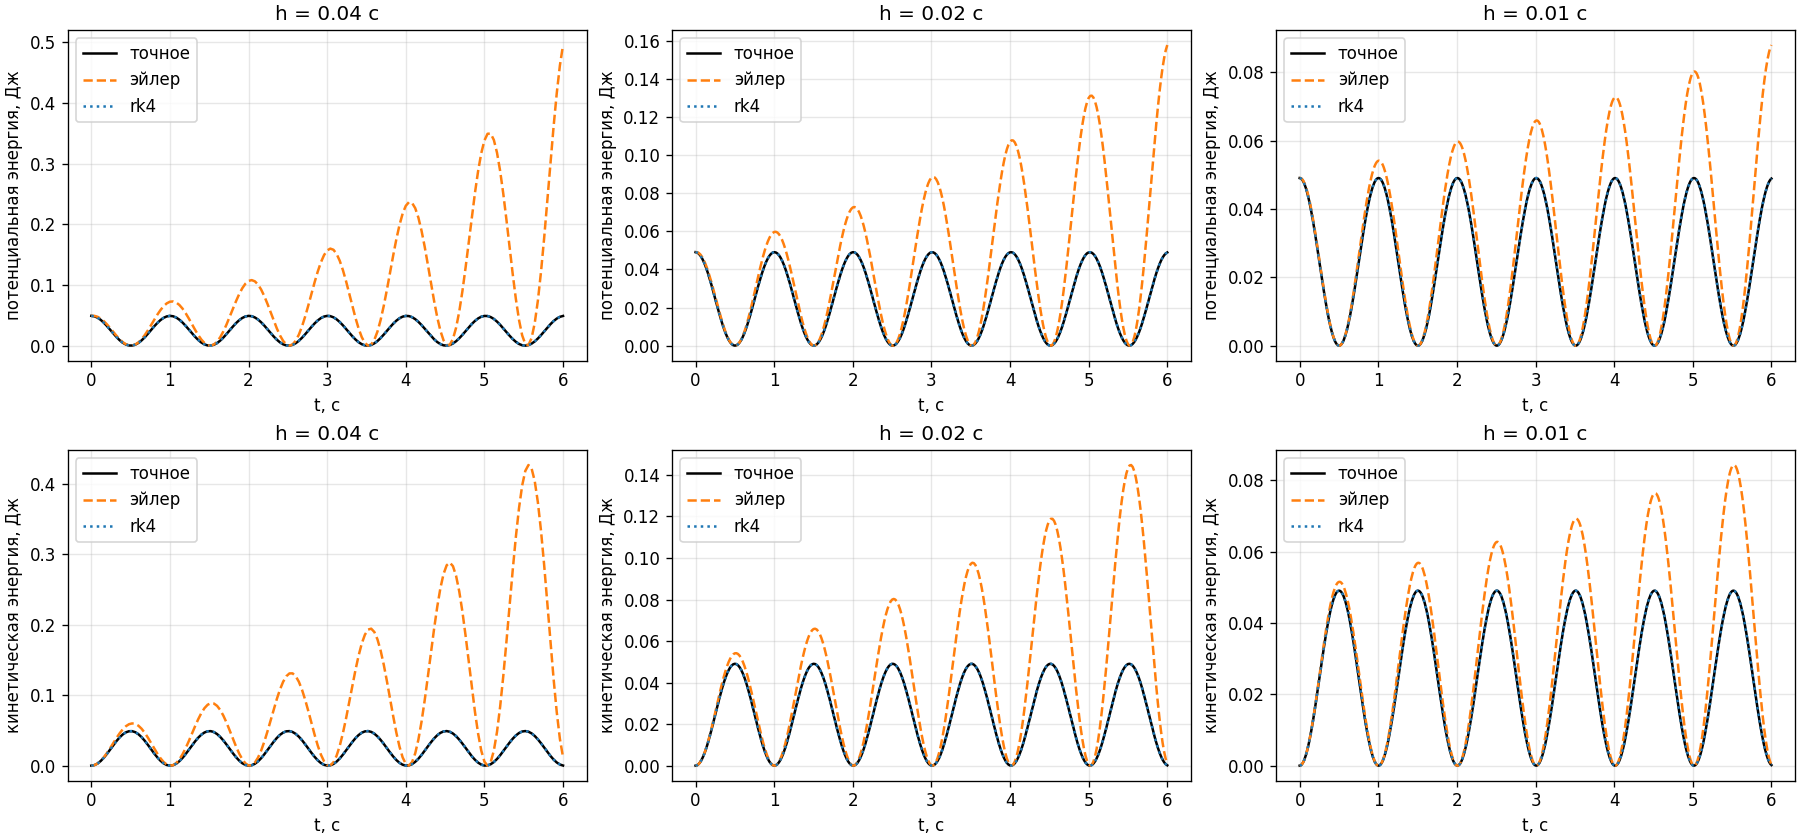

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7), constrained_layout=True)
for j, (h, (t, *solutions)) in enumerate(zip(steps, results)):
    for y, name, color, style in zip(solutions, names, colors, styles):
        e_p, e_k = energy(y)
        axes[0, j].plot(t, e_p, label=name, color=color, linestyle=style)
        axes[1, j].plot(t, e_k, label=name, color=color, linestyle=style)
    for i, label in enumerate(['потенциальная энергия, Дж', 'кинетическая энергия, Дж']):
        axes[i, j].set(title=f'h = {h} с', xlabel='t, с', ylabel=label)
        axes[i, j].grid(alpha=0.3)
        axes[i, j].legend()
plt.show()


При уменьшении шага ошибка обоих методов снижается. У явного эйлера полная энергия растёт, поэтому фазовая траектория раскручивается наружу. У rk4 ошибка угла при делении шага пополам уменьшается примерно в 16 раз; на графиках его решение практически совпадает с точным.